# Earthquake Damage Grade Prediction

Predicting building damage grade (1, 2, or 3) after the 2015 Nepal earthquake, using structural, geographic, and construction features.

Final approach: target-encoded geo features, engineered ratio/volume features, two KMeans-derived cluster features, and a class-weighted LightGBM classifier.

Final leaderboard score: **0.7274**

In [67]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


## Setup and Data Loading

In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder

richer=pd.read_csv('train_values.csv')
mg=pd.read_csv('train_labels.csv')
richer=richer.merge(mg,on='building_id',how='left')
richer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, classification_report
from lightgbm import LGBMClassifier

X=richer.drop(columns=['damage_grade','building_id']).copy()
y=richer['damage_grade']
X_dummies=pd.get_dummies(X)

X_train,X_test,y_train,y_test=train_test_split(X_dummies,y,test_size=0.2,random_state=45)
base_mod=LGBMClassifier(random_state=42)
base_mod.fit(X_train,y_train)
predictions=base_mod.predict(X_test)
print( classification_report(y_test,predictions))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.535579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 808
[LightGBM] [Info] Number of data points in the train set: 208480, number of used features: 66
[LightGBM] [Info] Start training from score -2.340467
[LightGBM] [Info] Start training from score -0.564618
[LightGBM] [Info] Start training from score -1.093207
              precision    recall  f1-score   support

           1       0.67      0.42      0.52      5051
           2       0.71      0.85      0.77     29722
           3       0.73      0.56      0.63     17348

    accuracy                           0.71     52121
   macro avg       0.70      0.61      0.64     52121
weighted avg       0.71      0.71      0.70     52121



In [94]:
acc=accuracy_score(y_test,predictions)
acc

0.7113063832236527

In [95]:
co=cohen_kappa_score(y_test,predictions, weights='quadratic')
co

0.5449078160331425

In [96]:
klop=y_test

In [97]:
from sklearn.feature_selection import mutual_info_classif 

X=richer.copy()
y=X.pop('damage_grade')
X=X.drop(columns='building_id')

for colname in X .select_dtypes('object'):
    X[colname],_=X[colname].factorize()
disc=X.dtypes=='int64'

def mi_scores(X,y,disc):
    mi=mutual_info_classif(X,y,discrete_features=disc)
    mi=pd.Series(mi,index=X.columns)
    mi=mi.sort_values(ascending=False)
    return mi

po=mi_scores(X,y,disc)
po

geo_level_3_id                            0.334123
geo_level_2_id                            0.240002
geo_level_1_id                            0.131877
foundation_type                           0.071000
ground_floor_type                         0.053564
has_superstructure_mud_mortar_stone       0.049215
other_floor_type                          0.047697
roof_type                                 0.040643
has_superstructure_cement_mortar_brick    0.032731
age                                       0.031299
count_floors_pre_eq                       0.020834
height_percentage                         0.018846
has_superstructure_rc_engineered          0.016171
has_superstructure_rc_non_engineered      0.012727
area_percentage                           0.012657
has_secondary_use_hotel                   0.004806
legal_ownership_status                    0.003991
has_superstructure_adobe_mud              0.003765
has_secondary_use_rental                  0.003471
plan_configuration             

## Initial Feature Exploration

Mutual information scores against `damage_grade` on the raw features, before any encoding or engineering, to get a first read on which fields matter.

## Exploratory Data Analysis

In [98]:
richer.tail()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2
260600,747594,21,9,9101,3,10,7,6,n,r,...,0,0,0,0,0,0,0,0,0,3


In [99]:
richer.damage_grade.value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

In [100]:
richer.foundation_type.value_counts()

foundation_type
r    219196
w     15118
u     14260
i     10579
h      1448
Name: count, dtype: int64

<Axes: xlabel='ground_floor_type', ylabel='count'>

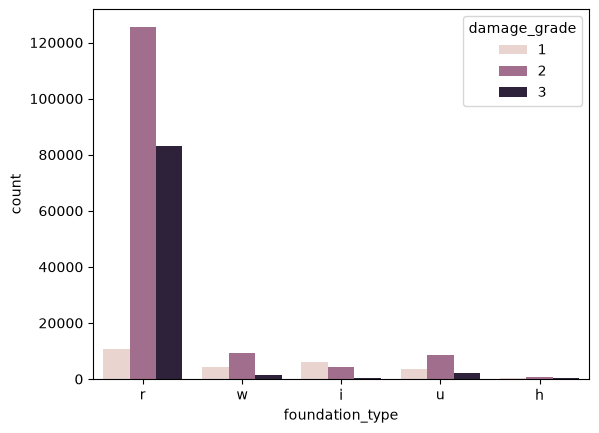

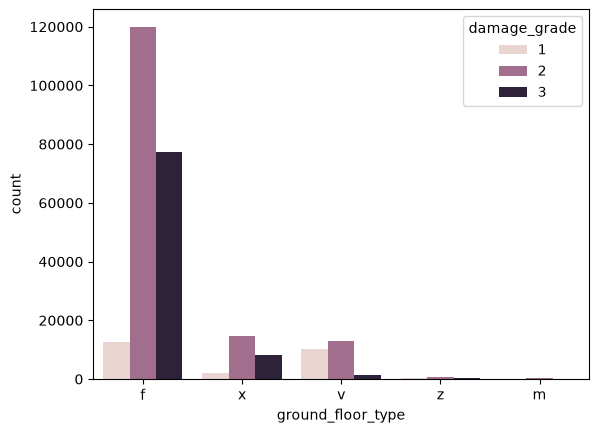

In [101]:
plt.figure()
sns.countplot(richer,x='foundation_type',hue='damage_grade')
plt.figure()
sns.countplot(richer,x='ground_floor_type',hue='damage_grade')

## Train/Test Split and Geo-Level Target Encoding

`geo_level_1_id`/`2`/`3` are high-cardinality location IDs — target encoding them (one encoder per damage grade) turns each into a per-grade probability instead of an unusable raw ID.

In [102]:
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
X=richer.drop(columns=['damage_grade','building_id'])
y=richer['damage_grade']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

cols_enc=['geo_level_1_id','geo_level_2_id','geo_level_3_id']
encoders = {}
for grade in [1,2,3]:
    y_class=(y_train==grade).astype(int)
    enc=TargetEncoder(cols=cols_enc,smoothing=10)
    train_enc=enc.fit_transform(X_train[cols_enc],y_class)
    train_enc.columns=[f'{col}_{grade}_prob' for col in cols_enc]
    test_enc=enc.transform(X_test[cols_enc])
    test_enc.columns=[f'{col}_{grade}_prob' for col in cols_enc]
    X_train=pd.concat([X_train,train_enc],axis=1)
    X_test=pd.concat([X_test,test_enc],axis=1)
    encoders[grade] = enc



    

In [103]:
X_train=X_train.drop(columns=['geo_level_1_id','geo_level_2_id','geo_level_3_id'])
X_test=X_test.drop(columns=['geo_level_1_id','geo_level_2_id','geo_level_3_id'])
X_train

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_secondary_use_other,geo_level_1_id_1_prob,geo_level_2_id_1_prob,geo_level_3_id_1_prob,geo_level_1_id_2_prob,geo_level_2_id_2_prob,geo_level_3_id_2_prob,geo_level_1_id_3_prob,geo_level_2_id_3_prob,geo_level_3_id_3_prob
102252,2,15,10,5,t,r,n,f,q,s,...,0,0.208136,0.228438,0.243395,0.698202,0.722611,0.704837,0.093661,0.048951,0.051767
215430,2,30,7,7,t,r,n,f,q,s,...,0,0.047968,0.000195,0.077236,0.568744,0.536650,0.587981,0.383288,0.463155,0.334783
5344,2,15,4,4,t,r,n,f,q,t,...,0,0.012967,0.008479,0.059932,0.178396,0.245781,0.404255,0.808637,0.745740,0.535813
70470,2,25,6,5,n,r,q,f,x,s,...,0,0.012967,0.002433,0.004150,0.178396,0.043796,0.043272,0.808637,0.953771,0.952577
153442,3,5,9,6,t,r,n,f,q,s,...,0,0.086219,0.127027,0.121577,0.666137,0.632432,0.706354,0.247643,0.240541,0.172069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60960,3,30,8,8,n,r,n,x,q,s,...,0,0.047968,0.024793,0.026950,0.568744,0.509642,0.467081,0.383288,0.465565,0.505969
137084,2,45,5,4,t,r,q,f,q,s,...,0,0.034878,0.095823,0.019046,0.766362,0.756757,0.843877,0.198760,0.147420,0.137077
194179,1,20,6,3,t,r,n,f,j,t,...,0,0.012967,0.003205,0.008774,0.178396,0.076923,0.094084,0.808637,0.919872,0.897143
137630,1,0,17,3,t,i,x,v,j,s,...,0,0.086219,0.333874,0.140180,0.666137,0.468395,0.495339,0.247643,0.197731,0.364481


## Feature Engineering

Two engineered features: `vol` (a rough building volume proxy) and `space_per_fam` (living space per family).

In [104]:
def make_vol(df):
    df['vol']=df['area_percentage']*df['height_percentage']
    return df
X_train=make_vol(X_train)
X_test=make_vol(X_test)
X_train

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,geo_level_1_id_1_prob,geo_level_2_id_1_prob,geo_level_3_id_1_prob,geo_level_1_id_2_prob,geo_level_2_id_2_prob,geo_level_3_id_2_prob,geo_level_1_id_3_prob,geo_level_2_id_3_prob,geo_level_3_id_3_prob,vol
102252,2,15,10,5,t,r,n,f,q,s,...,0.208136,0.228438,0.243395,0.698202,0.722611,0.704837,0.093661,0.048951,0.051767,50
215430,2,30,7,7,t,r,n,f,q,s,...,0.047968,0.000195,0.077236,0.568744,0.536650,0.587981,0.383288,0.463155,0.334783,49
5344,2,15,4,4,t,r,n,f,q,t,...,0.012967,0.008479,0.059932,0.178396,0.245781,0.404255,0.808637,0.745740,0.535813,16
70470,2,25,6,5,n,r,q,f,x,s,...,0.012967,0.002433,0.004150,0.178396,0.043796,0.043272,0.808637,0.953771,0.952577,30
153442,3,5,9,6,t,r,n,f,q,s,...,0.086219,0.127027,0.121577,0.666137,0.632432,0.706354,0.247643,0.240541,0.172069,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60960,3,30,8,8,n,r,n,x,q,s,...,0.047968,0.024793,0.026950,0.568744,0.509642,0.467081,0.383288,0.465565,0.505969,64
137084,2,45,5,4,t,r,q,f,q,s,...,0.034878,0.095823,0.019046,0.766362,0.756757,0.843877,0.198760,0.147420,0.137077,20
194179,1,20,6,3,t,r,n,f,j,t,...,0.012967,0.003205,0.008774,0.178396,0.076923,0.094084,0.808637,0.919872,0.897143,18
137630,1,0,17,3,t,i,x,v,j,s,...,0.086219,0.333874,0.140180,0.666137,0.468395,0.495339,0.247643,0.197731,0.364481,51


In [105]:
def make_spacefam(df):
    df['space_per_fam']=df['count_families']/df['area_percentage'].replace(0,np.nan)
    
    return df

X_train=make_spacefam(X_train)
X_test=make_spacefam(X_test)


In [106]:
X_train.space_per_fam.value_counts()
X_train.isna().sum()

count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo                 0
has_superstructure_rc_non_engineered      0
has_superstructure_rc_engineered          0
has_superstructure_other                  0
legal_ownership_status          

## Mutual Information After Feature Engineering

Re-checking MI scores now that the target-encoded geo probabilities and engineered ratios exist.

In [107]:
X=X_train.copy().dropna()
p=y_train.copy().to_numpy()
y=p



for colname in X.select_dtypes('object'):
    X[colname],_=X[colname].factorize()

disc=X.dtypes=='int64'

po=mi_scores(X,y,disc)


In [108]:
po

geo_level_3_id_3_prob                     0.281344
geo_level_3_id_2_prob                     0.273644
geo_level_2_id_3_prob                     0.235495
geo_level_2_id_2_prob                     0.235387
geo_level_2_id_1_prob                     0.222669
geo_level_3_id_1_prob                     0.177721
geo_level_1_id_3_prob                     0.134323
geo_level_1_id_2_prob                     0.134278
geo_level_1_id_1_prob                     0.133601
foundation_type                           0.071570
ground_floor_type                         0.054028
has_superstructure_mud_mortar_stone       0.049531
other_floor_type                          0.048098
roof_type                                 0.041062
has_superstructure_cement_mortar_brick    0.032641
age                                       0.031687
count_floors_pre_eq                       0.020900
vol                                       0.019995
height_percentage                         0.018897
has_superstructure_rc_engineere

## Scaling Features for Clustering

KMeans is distance-based, so features need to be on a comparable scale before clustering — MinMax scaling here.

In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn import set_config
set_config(transform_output="pandas")
sca=MinMaxScaler()
cols = X_train.select_dtypes(exclude=['object']).columns
X_trainsca=sca.fit_transform(X_train[cols])
X_testsca=sca.transform(X_test[cols])



In [110]:
X_trainsca.columns

Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other', 'geo_level_1_id_1_prob',
       'geo_level_2_id_1_prob', 'geo_level_3_id_1_prob',
       'geo_level_1

## KMeans Clustering — Geo Probability Clusters (`cluster3`)

Clustering on the target-encoded geo probabilities plus `foundation_type`, using the elbow method to pick `k`.

geo_level_3_id_1_prob    float64
geo_level_1_id_2_prob    float64
geo_level_2_id_2_prob    float64
geo_level_3_id_2_prob    float64
geo_level_1_id_3_prob    float64
geo_level_2_id_3_prob    float64
geo_level_3_id_3_prob    float64
foundation_type_h          int64
foundation_type_i          int64
foundation_type_r          int64
foundation_type_u          int64
foundation_type_w          int64
dtype: object


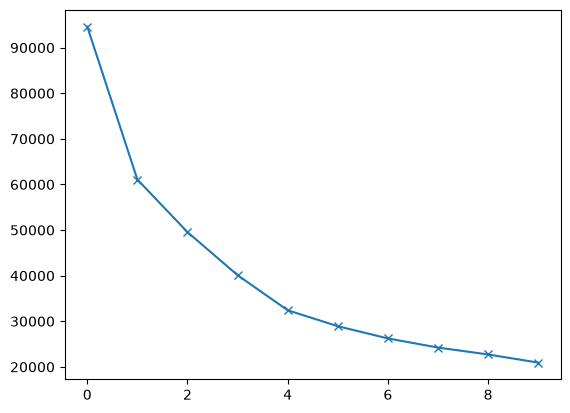

In [111]:
from sklearn.cluster import KMeans
X=X_train.copy()
X[['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other',
       'geo_level_1_id_1_prob', 'geo_level_2_id_1_prob',
       'geo_level_3_id_1_prob', 'geo_level_1_id_2_prob',
       'geo_level_2_id_2_prob', 'geo_level_3_id_2_prob',
       'geo_level_1_id_3_prob', 'geo_level_2_id_3_prob',
       'geo_level_3_id_3_prob']]=X_trainsca[['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other',
       'geo_level_1_id_1_prob', 'geo_level_2_id_1_prob',
       'geo_level_3_id_1_prob', 'geo_level_1_id_2_prob',
       'geo_level_2_id_2_prob', 'geo_level_3_id_2_prob',
       'geo_level_1_id_3_prob', 'geo_level_2_id_3_prob',
       'geo_level_3_id_3_prob']]
X_enc=pd.get_dummies(X[['geo_level_3_id_1_prob', 'geo_level_1_id_2_prob',
       'geo_level_2_id_2_prob', 'geo_level_3_id_2_prob',
       'geo_level_1_id_3_prob', 'geo_level_2_id_3_prob',
       'geo_level_3_id_3_prob','foundation_type']],dtype=int)
print(X_enc.dtypes) 

inertia=[]
for k in range(2,12):
    km=KMeans(n_clusters=k,n_init=10,random_state=3)
    km.fit(X_enc)
    inertia.append(km.inertia_)
plt.plot(inertia,marker='x')
    


In [112]:
km3=KMeans(n_clusters=5,n_init=10,random_state=3)
km3.fit(X_enc)
X['cluster3']=km3.predict(X_enc)

<Axes: xlabel='cluster3', ylabel='count'>

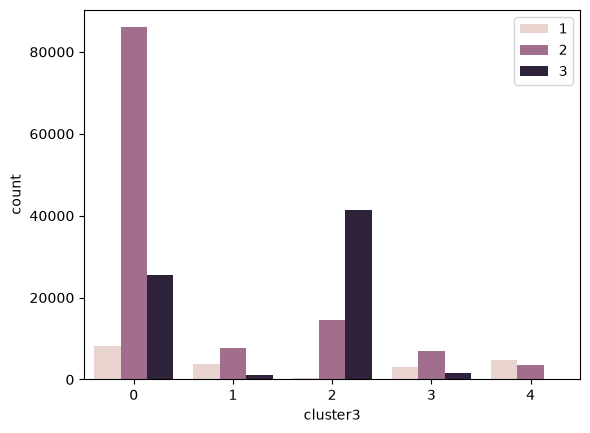

In [113]:
sns.countplot(X,x='cluster3',hue=y)

In [114]:
X=richer.copy()
y=X.pop('damage_grade')
X=X.drop(columns='building_id')

for colname in X .select_dtypes('object'):
    X[colname],_=X[colname].factorize()
disc=X.dtypes=='int64'

po=mi_scores(X,y,disc)
po

geo_level_3_id                            0.334123
geo_level_2_id                            0.240002
geo_level_1_id                            0.131877
foundation_type                           0.071000
ground_floor_type                         0.053564
has_superstructure_mud_mortar_stone       0.049215
other_floor_type                          0.047697
roof_type                                 0.040643
has_superstructure_cement_mortar_brick    0.032731
age                                       0.031299
count_floors_pre_eq                       0.020834
height_percentage                         0.018846
has_superstructure_rc_engineered          0.016171
has_superstructure_rc_non_engineered      0.012727
area_percentage                           0.012657
has_secondary_use_hotel                   0.004806
legal_ownership_status                    0.003991
has_superstructure_adobe_mud              0.003765
has_secondary_use_rental                  0.003471
plan_configuration             

## Applying `cluster3` to Train/Test

Rebuilding the same one-hot structure on the actual train/test splits (not just the full dataset) and assigning cluster labels with `.predict()`.

In [115]:
X_train

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,geo_level_2_id_1_prob,geo_level_3_id_1_prob,geo_level_1_id_2_prob,geo_level_2_id_2_prob,geo_level_3_id_2_prob,geo_level_1_id_3_prob,geo_level_2_id_3_prob,geo_level_3_id_3_prob,vol,space_per_fam
102252,2,15,10,5,t,r,n,f,q,s,...,0.228438,0.243395,0.698202,0.722611,0.704837,0.093661,0.048951,0.051767,50,0.100000
215430,2,30,7,7,t,r,n,f,q,s,...,0.000195,0.077236,0.568744,0.536650,0.587981,0.383288,0.463155,0.334783,49,0.142857
5344,2,15,4,4,t,r,n,f,q,t,...,0.008479,0.059932,0.178396,0.245781,0.404255,0.808637,0.745740,0.535813,16,0.250000
70470,2,25,6,5,n,r,q,f,x,s,...,0.002433,0.004150,0.178396,0.043796,0.043272,0.808637,0.953771,0.952577,30,0.166667
153442,3,5,9,6,t,r,n,f,q,s,...,0.127027,0.121577,0.666137,0.632432,0.706354,0.247643,0.240541,0.172069,54,0.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60960,3,30,8,8,n,r,n,x,q,s,...,0.024793,0.026950,0.568744,0.509642,0.467081,0.383288,0.465565,0.505969,64,0.125000
137084,2,45,5,4,t,r,q,f,q,s,...,0.095823,0.019046,0.766362,0.756757,0.843877,0.198760,0.147420,0.137077,20,0.200000
194179,1,20,6,3,t,r,n,f,j,t,...,0.003205,0.008774,0.178396,0.076923,0.094084,0.808637,0.919872,0.897143,18,0.166667
137630,1,0,17,3,t,i,x,v,j,s,...,0.333874,0.140180,0.666137,0.468395,0.495339,0.247643,0.197731,0.364481,51,0.058824


In [116]:
X_train[cols]=X_trainsca[cols]
X_test[cols]=X_testsca[cols]

enc_col=['geo_level_3_id_1_prob', 'geo_level_1_id_2_prob',
       'geo_level_2_id_2_prob', 'geo_level_3_id_2_prob',
       'geo_level_1_id_3_prob', 'geo_level_2_id_3_prob',
       'geo_level_3_id_3_prob','foundation_type']
X_train_hot = pd.get_dummies(X_train, columns=['foundation_type'], dtype=int)
X_test_hot = pd.get_dummies(X_test, columns=['foundation_type'], dtype=int)

X_train_hot = X_train_hot.reindex(columns=X_enc.columns, fill_value=0)
X_test_hot = X_test_hot.reindex(columns=X_enc.columns, fill_value=0)

km3.fit(X_enc)
X_train['cluster3'] = km3.predict(X_train_hot)
X_test['cluster3'] = km3.predict(X_test_hot)
X_train



,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,geo_level_3_id_1_prob,geo_level_1_id_2_prob,geo_level_2_id_2_prob,geo_level_3_id_2_prob,geo_level_1_id_3_prob,geo_level_2_id_3_prob,geo_level_3_id_3_prob,vol,space_per_fam,cluster3
102252,0.166667,0.015075,0.094737,0.100000,t,r,n,f,q,s,...,0.267325,0.733909,0.752550,0.726580,0.011918,0.049327,0.052077,0.027810,0.040000,0
215430,0.166667,0.030151,0.063158,0.166667,t,r,n,f,q,s,...,0.084830,0.551129,0.557032,0.605237,0.412176,0.468462,0.336799,0.027231,0.057143,0
5344,0.166667,0.015075,0.031579,0.066667,t,r,n,f,q,t,...,0.065824,0.000000,0.251212,0.414456,1.000000,0.754411,0.539042,0.008111,0.100000,2
70470,0.166667,0.025126,0.052632,0.100000,n,r,q,f,x,s,...,0.004558,0.000000,0.038845,0.039612,1.000000,0.964919,0.958320,0.016222,0.066667,2
153442,0.333333,0.005025,0.084211,0.133333,t,r,n,f,q,s,...,0.133530,0.688637,0.657737,0.728155,0.224718,0.243197,0.173105,0.030127,0.044444,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60960,0.333333,0.030151,0.073684,0.200000,n,r,n,x,q,s,...,0.029599,0.551129,0.528635,0.479695,0.412176,0.470900,0.509018,0.035921,0.050000,0
137084,0.166667,0.045226,0.042105,0.066667,t,r,q,f,q,s,...,0.020918,0.830144,0.788451,0.870958,0.157162,0.148968,0.137901,0.010429,0.080000,0
194179,0.000000,0.020101,0.052632,0.033333,t,r,n,f,j,t,...,0.009635,0.000000,0.073675,0.092375,1.000000,0.930616,0.902551,0.009270,0.066667,2
137630,0.000000,0.000000,0.168421,0.033333,t,i,x,v,j,s,...,0.153961,0.688637,0.485269,0.509038,0.224718,0.199878,0.366677,0.028389,0.023529,4


<Axes: xlabel='cluster3', ylabel='count'>

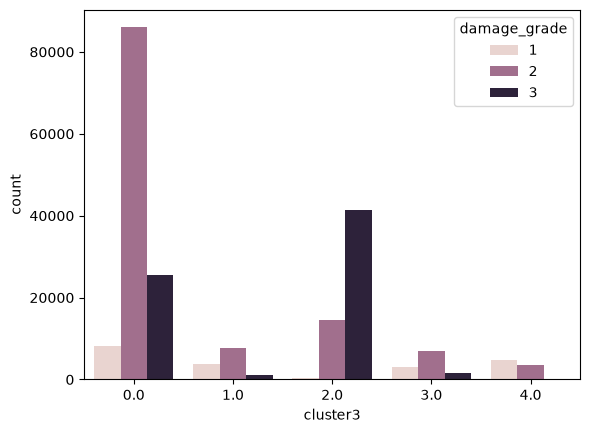

In [117]:
sns.countplot(X_train,x='cluster3',hue=y)

## Mutual Information After `cluster3`

In [118]:
X=X_train.copy()
p=y_train.copy().to_numpy()
y=p

for colname in X.select_dtypes('object'):
    X[colname],_=X[colname].factorize()
disc=X.dtypes=='int64'

po=mi_scores(X,y,disc)
po

geo_level_3_id_3_prob                     0.280111
geo_level_3_id_2_prob                     0.273301
geo_level_2_id_3_prob                     0.235074
geo_level_2_id_2_prob                     0.234657
geo_level_2_id_1_prob                     0.222517
cluster3                                  0.187218
geo_level_3_id_1_prob                     0.178619
geo_level_1_id_3_prob                     0.135437
geo_level_1_id_2_prob                     0.133407
geo_level_1_id_1_prob                     0.131170
foundation_type                           0.071570
has_superstructure_mud_mortar_stone       0.069310
ground_floor_type                         0.054028
other_floor_type                          0.048098
roof_type                                 0.041062
age                                       0.033509
has_superstructure_cement_mortar_brick    0.030538
count_floors_pre_eq                       0.027198
count_families                            0.024355
height_percentage              

In [119]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208480 entries, 102252 to 252875
Data columns (total 47 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   count_floors_pre_eq                     208480 non-null  float64
 1   age                                     208480 non-null  float64
 2   area_percentage                         208480 non-null  float64
 3   height_percentage                       208480 non-null  float64
 4   land_surface_condition                  208480 non-null  object 
 5   foundation_type                         208480 non-null  object 
 6   roof_type                               208480 non-null  object 
 7   ground_floor_type                       208480 non-null  object 
 8   other_floor_type                        208480 non-null  object 
 9   position                                208480 non-null  object 
 10  plan_configuration                      2084

## Second KMeans Clustering (`cluster4`)

A separate clustering pass on a different feature subset (structural + geo features), to see if it captures a different pattern than `cluster3`.

        count_floors_pre_eq       vol  space_per_fam  geo_level_1_id_3_prob  \
102252             0.166667  0.027810       0.040000               0.011918   
215430             0.166667  0.027231       0.057143               0.412176   
5344               0.166667  0.008111       0.100000               1.000000   
70470              0.166667  0.016222       0.066667               1.000000   
153442             0.333333  0.030127       0.044444               0.224718   
59621              0.166667  0.017381       0.050000               0.690400   
6378               0.333333  0.023175       0.000000               0.224718   
76660              0.333333  0.012746       0.100000               0.171595   
127844             0.333333  0.006952       0.200000               0.387100   
247904             0.166667  0.033604       0.040000               0.238516   

        geo_level_1_id_2_prob  geo_level_1_id_1_prob  foundation_type_h  \
102252               0.733909               0.585671   

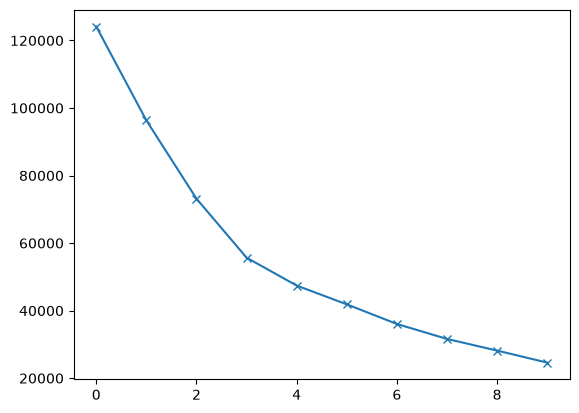

In [120]:
X=X_train.copy()
cols4=['count_floors_pre_eq','foundation_type','vol','space_per_fam','ground_floor_type','geo_level_1_id_3_prob','geo_level_1_id_2_prob','geo_level_1_id_1_prob']
X_hot=pd.get_dummies(X[cols4])
print(X_hot.head(10))

inertia=[]
for k in range(2,12):
    km=KMeans(n_clusters=k,n_init=10,random_state=3)
    km.fit(X_hot)
    inertia.append(km.inertia_)
plt.plot(inertia,marker='x')


<Axes: xlabel='cluster4', ylabel='count'>

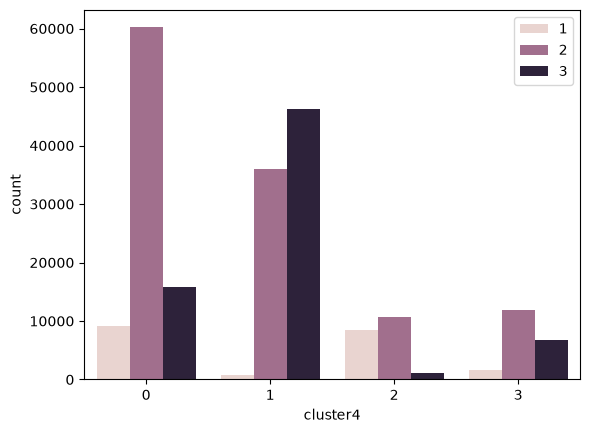

In [121]:
km4=KMeans(n_clusters=4,n_init=10,random_state=5)
km4.fit(X_hot)
X['cluster4']=km4.predict(X_hot)
sns.countplot(X,x='cluster4',hue=y)

In [122]:
X_train_hot=pd.get_dummies(X_train[cols4])
X_test_hot=pd.get_dummies(X_test[cols4])
X_train_hot=X_train_hot.reindex(columns=X_hot.columns)
X_test_hot=X_test_hot.reindex(columns=X_hot.columns)

km4.fit(X_hot)
X_train['cluster4'] = km4.predict(X_train_hot)
X_test['cluster4'] = km4.predict(X_test_hot)
X_train

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,geo_level_1_id_2_prob,geo_level_2_id_2_prob,geo_level_3_id_2_prob,geo_level_1_id_3_prob,geo_level_2_id_3_prob,geo_level_3_id_3_prob,vol,space_per_fam,cluster3,cluster4
102252,0.166667,0.015075,0.094737,0.100000,t,r,n,f,q,s,...,0.733909,0.752550,0.726580,0.011918,0.049327,0.052077,0.027810,0.040000,0,0
215430,0.166667,0.030151,0.063158,0.166667,t,r,n,f,q,s,...,0.551129,0.557032,0.605237,0.412176,0.468462,0.336799,0.027231,0.057143,0,1
5344,0.166667,0.015075,0.031579,0.066667,t,r,n,f,q,t,...,0.000000,0.251212,0.414456,1.000000,0.754411,0.539042,0.008111,0.100000,2,1
70470,0.166667,0.025126,0.052632,0.100000,n,r,q,f,x,s,...,0.000000,0.038845,0.039612,1.000000,0.964919,0.958320,0.016222,0.066667,2,1
153442,0.333333,0.005025,0.084211,0.133333,t,r,n,f,q,s,...,0.688637,0.657737,0.728155,0.224718,0.243197,0.173105,0.030127,0.044444,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60960,0.333333,0.030151,0.073684,0.200000,n,r,n,x,q,s,...,0.551129,0.528635,0.479695,0.412176,0.470900,0.509018,0.035921,0.050000,0,3
137084,0.166667,0.045226,0.042105,0.066667,t,r,q,f,q,s,...,0.830144,0.788451,0.870958,0.157162,0.148968,0.137901,0.010429,0.080000,0,0
194179,0.000000,0.020101,0.052632,0.033333,t,r,n,f,j,t,...,0.000000,0.073675,0.092375,1.000000,0.930616,0.902551,0.009270,0.066667,2,1
137630,0.000000,0.000000,0.168421,0.033333,t,i,x,v,j,s,...,0.688637,0.485269,0.509038,0.224718,0.199878,0.366677,0.028389,0.023529,4,2


## Mutual Information After `cluster4`

In [123]:
X=X_train.copy()
p=y_train.copy().to_numpy()
y=p

for colname in X.select_dtypes('object'):
    X[colname],_=X[colname].factorize()
disc=X.dtypes=='int64'

po=mi_scores(X,y,disc)
po

geo_level_3_id_3_prob                     0.279830
geo_level_3_id_2_prob                     0.270539
geo_level_2_id_2_prob                     0.234888
geo_level_2_id_3_prob                     0.234510
geo_level_2_id_1_prob                     0.223639
cluster3                                  0.185871
geo_level_3_id_1_prob                     0.179137
geo_level_1_id_3_prob                     0.135352
geo_level_1_id_2_prob                     0.134780
cluster4                                  0.133826
geo_level_1_id_1_prob                     0.133185
foundation_type                           0.071570
has_superstructure_mud_mortar_stone       0.070756
ground_floor_type                         0.054028
other_floor_type                          0.048098
roof_type                                 0.041062
has_superstructure_cement_mortar_brick    0.033197
age                                       0.030175
count_floors_pre_eq                       0.028021
count_families                 

## Dropping Low-Information Features

The `has_secondary_use_*` columns scored near zero on mutual information — dropping them to reduce noise going into the model.

In [124]:
def drops(df):
    df=df.drop(columns=['has_secondary_use_rental','has_secondary_use_agriculture','has_secondary_use_health_post','has_secondary_use_school','has_secondary_use_other','has_secondary_use_use_police','has_secondary_use_industry','has_secondary_use_institution','has_secondary_use_gov_office'])
    return df
X_train=drops(X_train)
X_test=drops(X_test)



In [125]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208480 entries, 102252 to 252875
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   count_floors_pre_eq                     208480 non-null  float64
 1   age                                     208480 non-null  float64
 2   area_percentage                         208480 non-null  float64
 3   height_percentage                       208480 non-null  float64
 4   land_surface_condition                  208480 non-null  object 
 5   foundation_type                         208480 non-null  object 
 6   roof_type                               208480 non-null  object 
 7   ground_floor_type                       208480 non-null  object 
 8   other_floor_type                        208480 non-null  object 
 9   position                                208480 non-null  object 
 10  plan_configuration                      2084

## Final Model: LightGBM Classifier

Class weights (`{1: 2.2, 2: 1.0, 3: 1.4}`) were tuned by hand to balance recall across classes — `damage_grade` is imbalanced (class 2 is the largest group), and the model initially under-predicted class 1.

In [154]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

X_hot=pd.get_dummies(X_train)

mod = LGBMClassifier(
    class_weight={1:2.5,2:1.2,3:1.4},
    n_estimators=500,
    num_leaves=50,
    min_child_samples=100,
    colsample_bytree=1,
    learning_rate=0.07,
    random_state=42
)
mod.fit(X_hot,y_train)
X_test_hot=pd.get_dummies(X_test)
preds=mod.predict(X_test_hot)
preds

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2268
[LightGBM] [Info] Number of data points in the train set: 208480, number of used features: 66
[LightGBM] [Info] Start training from score -1.755059
[LightGBM] [Info] Start training from score -0.713178
[LightGBM] [Info] Start training from score -1.087616


array([2, 3, 1, ..., 2, 3, 3], shape=(52121,))

## Feature Importance

In [155]:
imp=mod.feature_importances_

feats=pd.DataFrame({'imp':imp,
                'feat':X_hot.columns}).sort_values(ascending=False,by='imp')
feats.head(60)

,imp,feat
20,7662,geo_level_3_id_1_prob
26,6304,geo_level_3_id_3_prob
23,6077,geo_level_3_id_2_prob
27,6073,vol
1,5189,age
19,4961,geo_level_2_id_1_prob
22,4219,geo_level_2_id_2_prob
25,4023,geo_level_2_id_3_prob
28,3765,space_per_fam
2,2908,area_percentage


## Model Evaluation

In [156]:
acc=accuracy_score(y_test,preds)
acc

0.735231480593235

<Axes: >

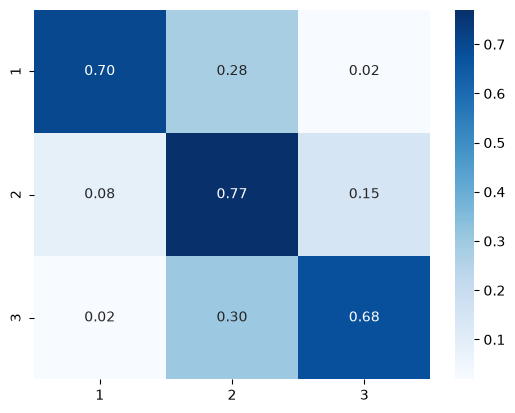

In [150]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,mod.predict(X_test_hot),normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[1,2,3], yticklabels=[1,2,3])

In [157]:
print(classification_report(y_test,preds))


              precision    recall  f1-score   support

           1       0.57      0.69      0.62      5051
           2       0.77      0.78      0.77     29722
           3       0.73      0.68      0.70     17348

    accuracy                           0.74     52121
   macro avg       0.69      0.72      0.70     52121
weighted avg       0.74      0.74      0.74     52121



In [158]:
final_preds = mod.predict(X_test_hot)

comparison = pd.DataFrame({
    'final (enginerrred features)': {
        'Accuracy': accuracy_score(y_test,preds),
        'Macro F1': f1_score(y_test,preds, average='macro'),
        'Quadratic Kappa': cohen_kappa_score(y_test,preds, weights='quadratic'),
    },
    'baseline model': {
        'Accuracy': accuracy_score(klop,predictions),
        'Macro F1': f1_score(klop,predictions, average='macro'),
        'Quadratic Kappa': cohen_kappa_score(klop,predictions, weights='quadratic'),
    }
}).T

comparison

,Accuracy,Macro F1,Quadratic Kappa
final (enginerrred features),0.735231,0.700511,0.625681
baseline model (engineered features + class weights),0.711306,0.640475,0.544908


## Results Summary

Final model reached 73.5% accuracy, 0.701 macro F1, and 0.626 quadratic weighted kappa — an improvement over the baseline's 71.1% / 0.640 / 0.545.

Target-encoded geo_level features were the strongest contributors overall, with geo_level_3_id_1_prob, geo_level_3_id_3_prob, and geo_level_3_id_2_prob ranking as the top three features by importance. Engineered volume and space-per-family ratios also ranked in the top five. Hand-tuned class weights improved recall on the minority class-1 buildings without hurting overall accuracy, and dropping the near-zero-information has_secondary_use_* columns simplified the feature set at no cost to performance.

Class 1 (light damage) remains the hardest to predict — precision 0.57, recall 0.69 — the smallest class with the most feature overlap against class 2. Class 2 and class 3 performed better, with F1 scores of 0.77 and 0.70 respectively.

## Generating the Submission File

Re-applies every transformation from training (target encoding, engineered features, scaling, both cluster models, column drops) to the competition test set, using the objects already fit on the training data.

In [153]:
sub_raw = pd.read_csv('test_values.csv')
building_ids = sub_raw['building_id']
Xs = sub_raw.drop(columns='building_id')

for grade in [1,2,3]:
    enc = encoders[grade]
    sub_enc = enc.transform(Xs[cols_enc])
    sub_enc.columns = [f'{col}_{grade}_prob' for col in cols_enc]
    Xs = pd.concat([Xs, sub_enc], axis=1)
Xs = Xs.drop(columns=cols_enc)

Xs = make_vol(Xs)
Xs = make_spacefam(Xs)
Xs['space_per_fam'] = Xs['space_per_fam'].fillna(X_train['space_per_fam'].median())

Xs[cols] = sca.transform(Xs[cols])

Xs_hot3 = pd.get_dummies(Xs, columns=['foundation_type'], dtype=int)
Xs_hot3 = Xs_hot3.reindex(columns=X_enc.columns, fill_value=0)
Xs['cluster3'] = km3.predict(Xs_hot3)

Xs_hot4 = pd.get_dummies(Xs[cols4])        
Xs_hot4 = Xs_hot4.reindex(columns=Xs_hot4.columns, fill_value=0)
Xs['cluster4'] = km4.predict(Xs_hot4)

Xs = drops(Xs)

Xs_final = pd.get_dummies(Xs)
Xs_final = Xs_final.reindex(columns=X_hot.columns, fill_value=0)  

final_preds = mod.predict(Xs_final)

submission = pd.DataFrame({
    'building_id': building_ids,
    'damage_grade': final_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

,building_id,damage_grade
0,300051,3
1,99355,2
2,890251,3
3,745817,1
4,421793,3
